# Sales Performance Dashboard
### Data Analytics Internship — Task 1
**Kinetrexa Software Pvt. Ltd.**

This notebook analyzes a real-world-style sales dataset to uncover revenue trends, top-performing products,
customer purchasing behavior, and regional sales performance.

**Sections**
1. Data Loading & Cleaning
2. Sales KPI Analysis
3. Revenue Trend Analysis
4. Product Performance
5. Regional Sales Analysis
6. Customer Purchasing Behavior
7. Business Insights & Recommendations


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)


## 1. Data Loading & Cleaning

In [2]:
df = pd.read_csv("../data/sales_data.csv", parse_dates=["order_date"])
print("Raw shape:", df.shape)
df.head()


Raw shape: (6015, 17)


,order_id,order_date,customer_id,customer_name,region,city,category,product_name,unit_price,quantity,discount_pct,gross_amount,discount_amount,net_amount,payment_method,is_returned,customer_rating
0,ORD103769,2024-08-01,CUST0680,Manisha Chopra,East,Guwahati,Beauty & Personal Care,Hair Dryer,640.82,1,0.0,640.82,0.00,640.82,Credit Card,False,5.0
1,ORD105393,2024-08-01,CUST0406,Vikram Rao,North,Lucknow,Sports & Fitness,Cycling Helmet,849.11,1,5.0,849.11,42.46,806.65,UPI,False,2.0
2,ORD103626,2024-08-01,CUST0406,Vikram Rao,North,Lucknow,Home & Kitchen,Mixer Grinder,7927.31,1,0.0,7927.31,0.00,7927.31,Credit Card,False,5.0
3,ORD103451,2024-08-01,CUST0478,Arjun Kapoor,South,Chennai,Fashion,Sunglasses,5663.99,1,0.0,5663.99,0.00,5663.99,Credit Card,False,4.0
4,ORD100631,2024-08-01,CUST0578,Kiran Patel,North,Chandigarh,Home & Kitchen,Vacuum Cleaner,3017.17,1,0.0,3017.17,0.00,3017.17,Debit Card,False,4.0


In [3]:
# --- Data quality check ---
print("Missing values:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().count() - df.drop_duplicates().shape[0])


Missing values:
 order_id            0
order_date          0
customer_id         0
customer_name       0
region              0
city                0
category            0
product_name        0
unit_price          0
quantity            0
discount_pct       10
gross_amount        0
discount_amount     0
net_amount          0
payment_method      0
is_returned         0
customer_rating    25
dtype: int64

Duplicate rows: 15


In [4]:
# --- Cleaning steps ---
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows")

# Fill missing discount_pct with 0 (no discount applied), missing rating with median
df["discount_pct"] = df["discount_pct"].fillna(0)
df["customer_rating"] = df["customer_rating"].fillna(df["customer_rating"].median())

# Correct dtypes
df["is_returned"] = df["is_returned"].astype(bool)
df["order_date"] = pd.to_datetime(df["order_date"])
df["order_month"] = df["order_date"].dt.to_period("M").astype(str)
df["order_year"] = df["order_date"].dt.year

# Exclude returned orders from revenue-generating analysis (kept for return-rate analysis)
df_valid = df[~df["is_returned"]].copy()

print("Clean shape:", df.shape)
print("Valid (non-returned) shape:", df_valid.shape)


Removed 15 duplicate rows
Clean shape: (6000, 19)
Valid (non-returned) shape: (5755, 19)


## 2. Sales KPI Analysis

In [5]:
total_revenue = df_valid["net_amount"].sum()
total_orders = df_valid["order_id"].nunique()
total_customers = df_valid["customer_id"].nunique()
avg_order_value = df_valid.groupby("order_id")["net_amount"].sum().mean()
return_rate = df["is_returned"].mean() * 100
avg_rating = df_valid["customer_rating"].mean()

kpis = pd.DataFrame({
    "KPI": ["Total Revenue (INR)", "Total Orders", "Unique Customers",
            "Avg Order Value (INR)", "Return Rate (%)", "Avg Customer Rating"],
    "Value": [round(total_revenue, 2), total_orders, total_customers,
              round(avg_order_value, 2), round(return_rate, 2), round(avg_rating, 2)]
})
kpis


,KPI,Value
0,Total Revenue (INR),59260019.71
1,Total Orders,5755.00
2,Unique Customers,777.00
3,Avg Order Value (INR),10297.14
4,Return Rate (%),4.08
5,Avg Customer Rating,3.90


## 3. Revenue Trend Analysis

In [6]:
monthly_revenue = df_valid.groupby("order_month")["net_amount"].sum().reset_index()

fig = px.line(monthly_revenue, x="order_month", y="net_amount", markers=True,
              title="Monthly Revenue Trend", labels={"net_amount": "Revenue (INR)", "order_month": "Month"})
fig.update_layout(xaxis_tickangle=-45)
fig.show()


C:\Users\sivap\AppData\Local\Temp\ipykernel_2852\3557090486.py:5: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



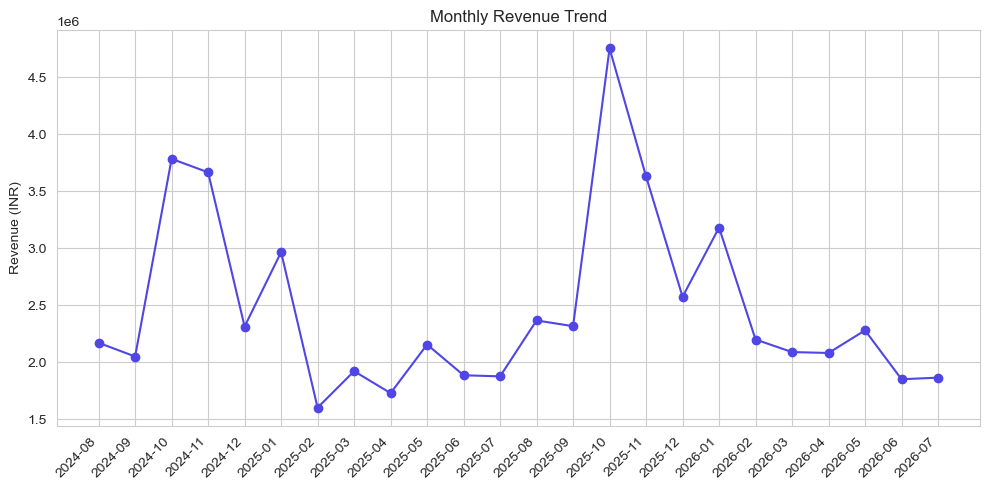

In [7]:
fig, ax = plt.subplots()
ax.plot(monthly_revenue["order_month"], monthly_revenue["net_amount"], marker="o", color="#4F46E5")
ax.set_title("Monthly Revenue Trend")
ax.set_ylabel("Revenue (INR)")
ax.set_xticklabels(monthly_revenue["order_month"], rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../reports/monthly_revenue_trend.png", dpi=150)
plt.show()


## 4. Product & Category Performance

In [8]:
category_perf = (df_valid.groupby("category")["net_amount"]
                  .sum().sort_values(ascending=False).reset_index())

fig = px.bar(category_perf, x="category", y="net_amount", color="category",
             title="Revenue by Category", labels={"net_amount": "Revenue (INR)"})
fig.show()


In [9]:
top_products = (df_valid.groupby("product_name")["net_amount"]
                 .sum().sort_values(ascending=False).head(10).reset_index())

fig = px.bar(top_products, x="net_amount", y="product_name", orientation="h",
             title="Top 10 Products by Revenue", labels={"net_amount": "Revenue (INR)", "product_name": ""})
fig.update_layout(yaxis={"categoryorder": "total ascending"})
fig.show()


## 5. Regional Sales Analysis

In [10]:
region_perf = (df_valid.groupby("region")["net_amount"]
               .agg(["sum", "count"]).rename(columns={"sum": "revenue", "count": "orders"})
               .sort_values("revenue", ascending=False).reset_index())
region_perf


,region,revenue,orders
0,North,17574099.41,1712
1,West,14453703.07,1403
2,South,13796184.51,1359
3,East,13436032.72,1281


In [11]:
fig = px.pie(region_perf, names="region", values="revenue", title="Revenue Share by Region", hole=0.4)
fig.show()


In [12]:
city_perf = (df_valid.groupby(["region", "city"])["net_amount"]
             .sum().sort_values(ascending=False).head(10).reset_index())

fig = px.bar(city_perf, x="net_amount", y="city", color="region", orientation="h",
             title="Top 10 Cities by Revenue")
fig.update_layout(yaxis={"categoryorder": "total ascending"})
fig.show()


## 6. Customer Purchasing Behavior

In [13]:
payment_dist = df_valid["payment_method"].value_counts(normalize=True).mul(100).round(1)
fig = px.bar(payment_dist, title="Payment Method Preference (%)",
             labels={"value": "% of Orders", "index": "Payment Method"})
fig.show()


In [14]:
cust_order_freq = df_valid.groupby("customer_id")["order_id"].nunique()
fig = px.histogram(cust_order_freq, nbins=20, title="Distribution of Orders per Customer",
                    labels={"value": "Number of Orders"})
fig.show()

print("Repeat customer rate:",
      round((cust_order_freq > 1).mean() * 100, 1), "%")


Repeat customer rate: 87.6 %


## 7. Business Insights & Recommendations

In [15]:
top_region = region_perf.iloc[0]["region"]
top_category = category_perf.iloc[0]["category"]
top_product = top_products.iloc[0]["product_name"]
peak_month = monthly_revenue.loc[monthly_revenue["net_amount"].idxmax(), "order_month"]

print(f"""
KEY INSIGHTS
------------
1. Total revenue generated: INR {total_revenue:,.0f} across {total_orders:,} orders from {total_customers:,} customers.
2. {top_region} is the highest-revenue region, contributing INR {region_perf.iloc[0]['revenue']:,.0f}.
3. '{top_category}' is the best-performing category; '{top_product}' is the single top-selling product.
4. Peak revenue month: {peak_month} — likely driven by festive/seasonal demand.
5. Repeat purchase rate is {round((cust_order_freq > 1).mean() * 100, 1)}%, showing room to grow customer loyalty.
6. Return rate stands at {return_rate:.1f}% — worth monitoring for quality/fit issues in underperforming SKUs.
7. Average order value is INR {avg_order_value:,.0f}; bundling or upsell offers could raise this further.

RECOMMENDATIONS
----------------
- Increase marketing spend in {top_region} during the pre-festive season to capitalize on demand.
- Run cross-sell bundles pairing top category items with lower-performing categories.
- Launch a loyalty/rewards program to convert one-time buyers into repeat customers.
- Investigate high-return products/categories to reduce return rate and protect margins.
- Double down on the payment method customers prefer most to reduce checkout friction.
""")



KEY INSIGHTS
------------
1. Total revenue generated: INR 59,260,020 across 5,755 orders from 777 customers.
2. North is the highest-revenue region, contributing INR 17,574,099.
3. 'Electronics' is the best-performing category; 'Laptop' is the single top-selling product.
4. Peak revenue month: 2025-10 — likely driven by festive/seasonal demand.
5. Repeat purchase rate is 87.6%, showing room to grow customer loyalty.
6. Return rate stands at 4.1% — worth monitoring for quality/fit issues in underperforming SKUs.
7. Average order value is INR 10,297; bundling or upsell offers could raise this further.

RECOMMENDATIONS
----------------
- Increase marketing spend in North during the pre-festive season to capitalize on demand.
- Run cross-sell bundles pairing top category items with lower-performing categories.
- Launch a loyalty/rewards program to convert one-time buyers into repeat customers.
- Investigate high-return products/categories to reduce return rate and protect margins.
- Doubl

In [16]:
# Export summary tables for the dashboard / report
kpis.to_csv("../reports/kpis_summary.csv", index=False)
category_perf.to_csv("../reports/category_performance.csv", index=False)
region_perf.to_csv("../reports/region_performance.csv", index=False)
top_products.to_csv("../reports/top_products.csv", index=False)
monthly_revenue.to_csv("../reports/monthly_revenue.csv", index=False)
print("Exported summary CSVs to ../reports/")


Exported summary CSVs to ../reports/
